# 模型评估与验证（sklearn 实战）

> 📌 **出处**：李沐《实用机器学习》「模型评估、过拟合与欠拟合、模型验证、方差与偏差」
> 🎯 **目标**：搞懂「怎么判断模型好不好、好在哪里」——训练/验证/测试集划分、K 折交叉验证，以及用**学习曲线**诊断欠拟合/过拟合。

## 为什么不能只看「训练集上的准确率」

模型在训练集上 99% 不代表它真的强——可能只是**背下了答案**（过拟合）。评估的关键：**在模型没见过的数据上测**。


In [1]:
# ==================== 环境准备 ====================
import torch
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'PingFang SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

蓝 = '#2b7bba'; 橙 = '#e69f00'; 灰 = '#999999'; 红 = '#d62728'; 绿 = '#2ca02c'; 紫 = '#9467bd'
np.random.seed(0); torch.manual_seed(0)

print("✓ 环境就绪：torch", torch.__version__)


✓ 环境就绪：torch 2.14.0+cpu


## 1. 训练 / 验证 / 测试集：三个角色的分工

| 数据集 | 干什么 |
| --- | --- |
| **训练集** | 训练模型参数 |
| **验证集** | 调超参数、选模型、早停（间接参与，会「偷看」） |
| **测试集** | 只在**最后**用一次，报告真实泛化能力 |

原则：**测试集必须「出箱封存」，只在最终评估时打开一次。**


In [2]:
# ---- 划分 + 用验证集选超参数，最后才上测试集 ----
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier

X, y = load_breast_cancer(return_X_y=True)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=0)
Xtr, Xva, ytr, yva = train_test_split(Xtr, ytr, test_size=0.25, random_state=0)  # 0.8*0.25=0.2

print(f"训练 {len(Xtr)} / 验证 {len(Xva)} / 测试 {len(Xte)}")

# 用验证集选「树的数量」这个超参数
best_n, best_acc = None, -1
for n in [5, 10, 20, 50, 100]:
    m = RandomForestClassifier(n_estimators=n, random_state=0).fit(Xtr, ytr)
    acc = m.score(Xva, yva)
    print(f"  n_estimators={n:3d} -> 验证准确率 {acc:.4f}")
    if acc > best_acc:
        best_n, best_acc = n, acc
print(f"\n最优 n_estimators={best_n}，在测试集上最终评估：",
      f"{RandomForestClassifier(n_estimators=best_n, random_state=0).fit(Xtr, ytr).score(Xte, yte):.4f}")


训练 341 / 验证 114 / 测试 114
  n_estimators=  5 -> 验证准确率 0.9561
  n_estimators= 10 -> 验证准确率 0.9386
  n_estimators= 20 -> 验证准确率 0.9474
  n_estimators= 50 -> 验证准确率 0.9561
  n_estimators=100 -> 验证准确率 0.9561

最优 n_estimators=5，在测试集上最终评估： 0.9649


## 2. K 折交叉验证：数据少时的「更可靠」评估

数据少时，一次划分可能碰巧好/坏。**K 折交叉验证**：把数据切成 K 份，轮流拿一份当验证、其余训练，取 K 次平均。每份数据都当过验证集，评估更稳。


In [3]:
# ---- K 折交叉验证 ----
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=0)
scores = cross_val_score(dt, X, y, cv=5)
print("决策树 5 折交叉验证准确率：", [f"{s:.3f}" for s in scores])
print("平均：", f"{scores.mean():.4f}  ±  {scores.std():.4f}")


决策树 5 折交叉验证准确率： ['0.904', '0.921', '0.912', '0.947', '0.903']
平均： 0.9174  ±  0.0164


## 3. 学习曲线：诊断欠拟合 / 过拟合

画「训练集误差」和「验证集误差」随训练样本数变化的曲线：

- 两者都高 → **欠拟合**（高偏差），模型太简单；
- 训练低、验证高，且差距大 → **过拟合**（高方差），模型太复杂；
- 两者都低且接近 → 刚好。


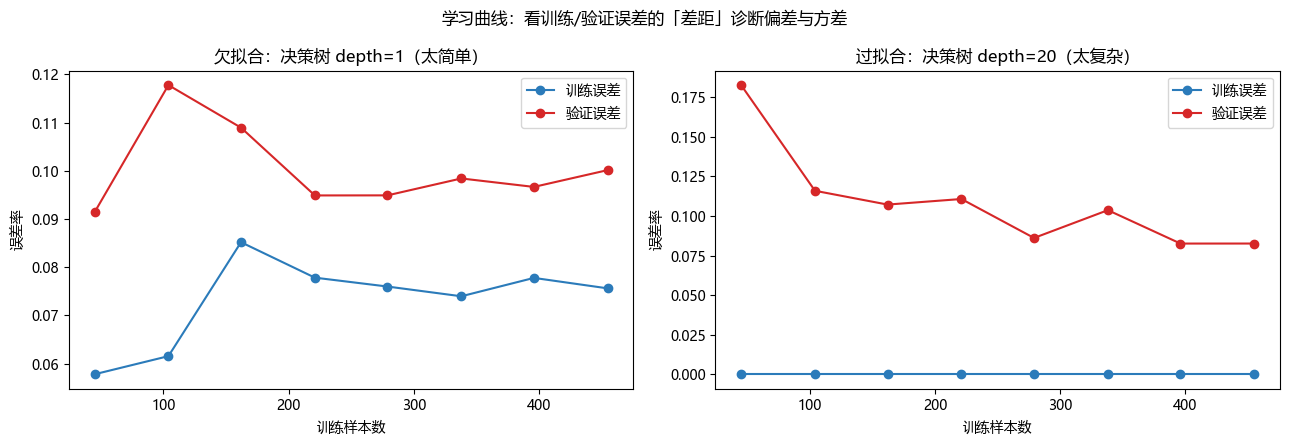

In [4]:
# ---- 学习曲线：模型复杂度 vs 训练/验证误差 ----
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (name, m) in zip(axes, [
    ("欠拟合：决策树 depth=1（太简单）", DecisionTreeClassifier(max_depth=1, random_state=0)),
    ("过拟合：决策树 depth=20（太复杂）", DecisionTreeClassifier(max_depth=20, random_state=0)),
]):
    train_sizes, tr_scores, va_scores = learning_curve(
        m, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 8), random_state=0)
    tr_mean = 1 - tr_scores.mean(axis=1)
    va_mean = 1 - va_scores.mean(axis=1)
    ax.plot(train_sizes, tr_mean, 'o-', color=蓝, label='训练误差')
    ax.plot(train_sizes, va_mean, 'o-', color=红, label='验证误差')
    ax.set_xlabel('训练样本数'); ax.set_ylabel('误差率')
    ax.set_title(name); ax.legend()

plt.suptitle("学习曲线：看训练/验证误差的「差距」诊断偏差与方差")
plt.tight_layout()
plt.show()


## 小结

| 概念 | 一句话直觉 |
| --- | --- |
| 训练/验证/测试 | 训练学参数，验证调超参，测试只最后评一次 |
| K 折交叉验证 | 轮流当验证集，评估更稳 |
| 学习曲线 | 看训练/验证误差差距：都高=欠拟合，差距大=过拟合 |
| 偏差 vs 方差 | 欠拟合=高偏差；过拟合=高方差 |

> 🔑 **记忆**：**测试集出箱封存**；数据少用 **K 折**；诊断用 **学习曲线**——「训练验证都高 → 加复杂度；训练低验证高 → 加正则/增数据」。
